In [1]:
import sys
print(sys.executable)

c:\Users\amedi\Downloads\Projects\Market Data Pipeline\venv\Scripts\python.exe


In [2]:
# STEP 1:  Imports

import requests
import pandas as pd
import sqlite3
from datetime import datetime

In [3]:
# STEP 2: Fetch Live Data (API Ingestion)

def fetch_price():
    url = "https://api.binance.com/api/v3/ticker/price?symbol=BTCUSDT"
    response = requests.get(url)
    data = response.json()
    
    price = float(data["price"])
    timestamp = datetime.now()
    
    return price, timestamp

In [4]:
# Testing

price, timestamp = fetch_price()
print(price, timestamp)

67337.88 2026-04-04 21:42:55.604850


In [5]:
# STEP 3: Create SQL Database

conn = sqlite3.connect("market_data.db")
cursor = conn.cursor()

cursor.execute("""
CREATE TABLE IF NOT EXISTS market_data (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    timestamp TEXT,
    price REAL,
    price_change REAL,
    moving_avg REAL,
    volatility REAL
)
""")

conn.commit()


In [6]:
# STEP 4: Data Processing Logic

import pandas as pd

def calculate_metrics(df, new_price):
    if len(df) == 0:
        return 0, new_price, 0

    last_price = df.iloc[-1]["price"]
    price_change = ((new_price - last_price) / last_price) * 100

    prices = df["price"].tolist() + [new_price]

    moving_avg = sum(prices[-5:]) / len(prices[-5:])

    volatility = pd.Series(prices[-5:]).std()

    return price_change, moving_avg, volatility

In [7]:
def detect_spike(price_change):
    if abs(price_change) > 1.5:
        return "⚠️ Market Spike Detected!"
    return "Normal"

In [8]:
# STEP 5: Store Data in SQL

def store_data(price, timestamp):
    df = pd.read_sql("SELECT * FROM market_data", conn)

    price_change, moving_avg, volatility = calculate_metrics(df, price)

    alert = detect_spike(price_change)
    print(alert)

    cursor.execute("""
    INSERT INTO market_data (timestamp, price, price_change, moving_avg, volatility)
    VALUES (?, ?, ?, ?, ?)
    """, (str(timestamp), price, price_change, moving_avg, volatility))

    conn.commit()

In [9]:
price, timestamp = fetch_price()
store_data(price, timestamp)

print("Data inserted!")

Normal
Data inserted!


In [10]:
# STEP 6: Simulate Real-Time Pipeline

import time

for i in range(10):  # collect 10 data points
    price, timestamp = fetch_price()
    store_data(price, timestamp)
    
    print(f"Inserted: {price} at {timestamp}")
    time.sleep(5)  # fetch every 5 seconds

Normal
Inserted: 67337.87 at 2026-04-04 21:42:56.305142
Normal
Inserted: 67337.88 at 2026-04-04 21:43:02.180918
Normal
Inserted: 67337.88 at 2026-04-04 21:43:08.360777
Normal
Inserted: 67337.87 at 2026-04-04 21:43:23.668693
Normal
Inserted: 67337.88 at 2026-04-04 21:43:28.990116
Normal
Inserted: 67337.88 at 2026-04-04 21:43:34.499448
Normal
Inserted: 67337.87 at 2026-04-04 21:43:39.846551
Normal
Inserted: 67337.87 at 2026-04-04 21:43:45.432055
Normal
Inserted: 67337.88 at 2026-04-04 21:44:00.967070
Normal
Inserted: 67337.87 at 2026-04-04 21:44:06.703521


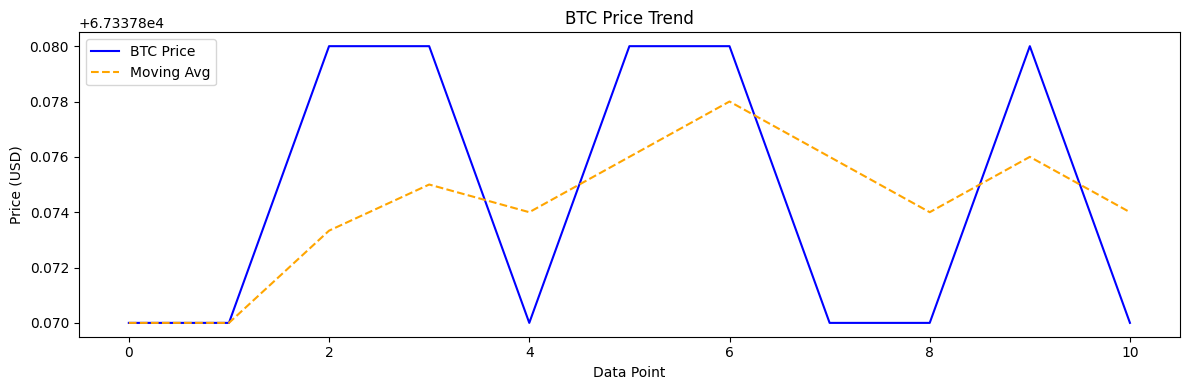

In [11]:
# STEP 7: View Data

import matplotlib.pyplot as plt

df = pd.read_sql("SELECT * FROM market_data", conn)

plt.figure(figsize=(12, 4))
plt.plot(df["price"], label="BTC Price", color="blue")
plt.plot(df["moving_avg"], label="Moving Avg", color="orange", linestyle="--")
plt.title("BTC Price Trend")
plt.xlabel("Data Point")
plt.ylabel("Price (USD)")
plt.legend()
plt.tight_layout()
plt.show()          # ✅ FIX: without this, the chart never renders in Jupyter

<Axes: title={'center': 'BTC Price Trend'}>

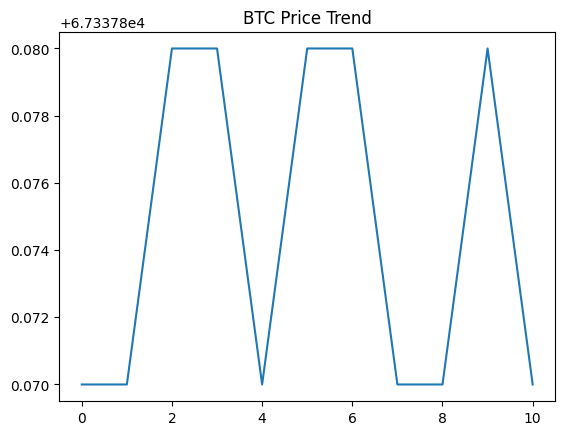

In [12]:
import matplotlib
df["price"].plot(title="BTC Price Trend")

In [14]:
# STEP 9 (BONUS): AI Insight (Optional)

def generate_insight(df):
    if len(df) < 2:
        return "Not enough data"
    
    latest = df.iloc[-1]
    
    if latest["price_change"] > 0:
        return "Price is trending upward 📈"
    else:
        return "Price is trending downward 📉"

In [15]:
df = pd.read_sql("SELECT * FROM market_data", conn)
print(generate_insight(df))

Price is trending downward 📉
